In [1]:
from wings.config import PROCESSED_DATA_DIR

dataset_folder = PROCESSED_DATA_DIR / "detection"

image_records = []
for split in ("train", "val", "test"):
    for img_path in sorted((dataset_folder / "images" / split).iterdir()):
        label_path = dataset_folder / "labels" / split / (img_path.stem + ".txt")
        if label_path.exists():
            image_records.append((img_path, label_path))


len(image_records)

2026-04-23 19:03:54.548 | INFO     | wings.config:<module>:40 - PROJ_ROOT path is: C:\Users\X\projects\bees
2026-04-23 19:03:56.347 | INFO     | wings.config:<module>:64 - torch.cuda.get_device_name()='NVIDIA RTX A3000 12GB Laptop GPU'


21722

In [72]:
from ultralytics import YOLO
from wings.config import MODELS_DIR


model = YOLO(MODELS_DIR / "trained_yolo.pt")

In [27]:
import random

sample = random.choice(image_records)

img_path = sample[0]
label_path = sample[1]

result = model(img_path)[0]

boxes = result.boxes
result.show()

print(boxes.xywh.cpu().numpy().squeeze())


image 1/1 C:\Users\X\projects\bees\data\processed\detection\images\train\RO-0045-TM-1-1993-004795.dw.png: 320x640 1 wing, 166.9ms
Speed: 3.1ms preprocess, 166.9ms inference, 3.1ms postprocess per image at shape (1, 3, 320, 640)
[     546.95      257.63       642.1      257.35]



image 1/1 C:\Users\X\projects\bees\data\processed\detection\images\train\RO-0008-BH-9-1982-003220.dw.png: 352x640 1 wing, 51.2ms
Speed: 2.5ms preprocess, 51.2ms inference, 0.4ms postprocess per image at shape (1, 3, 352, 640)


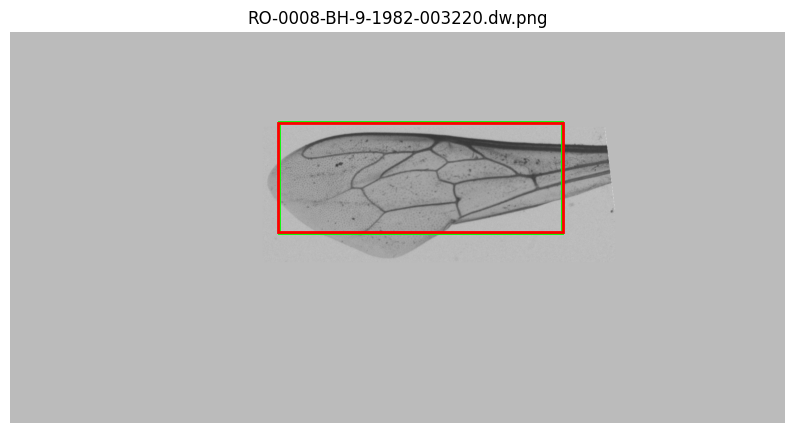

In [105]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample = random.choice(image_records)

img_path = sample[0]
label_path = sample[1]
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]
class_id, cx, cy, bw, bh = map(float, label_path.read_text(encoding="utf-8").split())
# YOLO box format: [class_id, cx, cy, bw, bh] (normalized)
x1 = int((cx - bw / 2) * w)
y1 = int((cy - bh / 2) * h)
box_w = int(bw * w)
box_h = int(bh * h)



fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="lime",
        facecolor="none",
    )
)
result = model(img_path)[0]
boxes = result.boxes
cx, cy, bw, bh = boxes.xywh.cpu().numpy().squeeze()

x2 = int((cx - bw / 2))
y2 = int((cy - bh / 2))
box_w = int(bw)
box_h = int(bh)
ax.add_patch(
    patches.Rectangle(
        (x2, y2),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
)
ax.set_title(f"{img_path.name}")
ax.axis("off")
plt.show()

# Raw dataset

In [ ]:
from wings.detection.dataset import collect_image_paths
from wings.config import RAW_DATA_DIR, COUNTRIES

image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)
image_paths = collect_image_paths(RAW_DATA_DIR, )
import random

sample_path = random.choice(image_paths)
sample_path

2026-04-23 19:28:38.946 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw


WindowsPath('C:/Users/X/projects/bees/data/raw/PL-wing-images/PL-0019-000400-L.dw.png')


image 1/1 C:\Users\X\projects\bees\data\raw\HR-wing-images\HR-0074-139-101359-R.dw.png: 288x640 1 wing, 138.6ms
Speed: 1.9ms preprocess, 138.6ms inference, 4.3ms postprocess per image at shape (1, 3, 288, 640)


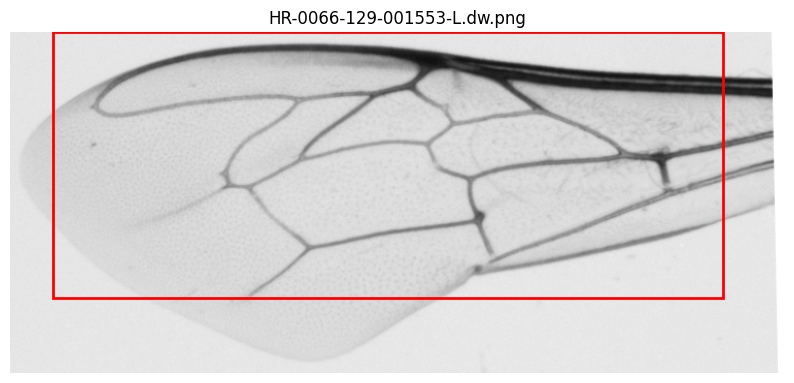

In [180]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

sample_path = random.choice(image_paths)

img_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


result = model(sample_path)[0]
boxes = result.boxes
conf = boxes.conf.cpu().numpy()
cx, cy, bw, bh = boxes.xywh[np.argmax(conf)]

x2 = int((cx - bw / 2))
y2 = int((cy - bh / 2))
box_w = int(bw)
box_h = int(bh)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(img)
ax.add_patch(
    patches.Rectangle(
        (x2, y2),
        box_w,
        box_h,
        linewidth=2,
        edgecolor="red",
        facecolor="none",
    )
)
ax.set_title(f"{img_path.name}")
ax.axis("off")
plt.show()

In [220]:
# test
from pathlib import Path
img_path = Path("C:\\Users\\X\\projects\\bees\\data\\raw\\HR-wing-images\\HR-0066-129-001553-L.dw.png")
img_path = Path("C:\\Users\\X\\projects\\bees\\data\\raw\\GR-wing-images\\GR-0152-2005-TR-066-6.dw.png")
result = model(sample_path)[0]
boxes = result.boxes.cpu().numpy()
# result.show()
print(boxes.xywh)
print(boxes.conf)


image 1/1 C:\Users\X\projects\bees\data\raw\GR-wing-images\GR-0152-2005-TR-066-6.dw.png: 480x640 (no detections), 178.8ms
Speed: 811.6ms preprocess, 178.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
[]
[]


# Crop box from image


image 1/1 C:\Users\X\projects\bees\data\raw\PL-wing-images\PL-0242-LP-091-100655-L.dw.png: 288x640 1 wing, 47.4ms
Speed: 2.3ms preprocess, 47.4ms inference, 0.6ms postprocess per image at shape (1, 3, 288, 640)


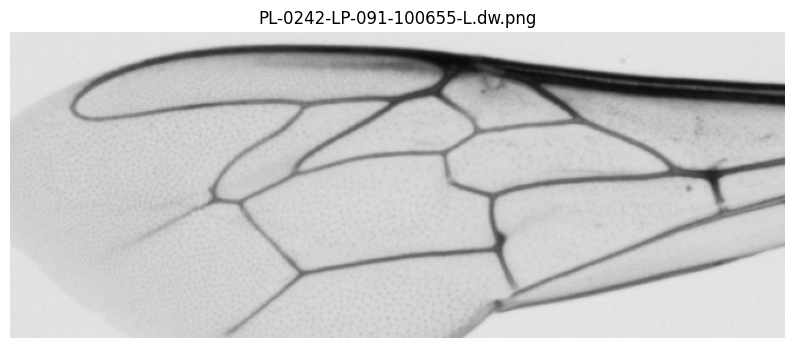

In [322]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

sample_path = random.choice(image_paths)

img_bgr = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Could not read image: {img_path}")



result = model(sample_path)[0]
if len(result) > 0:
    boxes = result.boxes.cpu().numpy()
    conf = boxes.conf
    x1, y1, x2, y2 = boxes.xyxy[np.argmax(conf)]

    xmin, xmax = int(min(x1, x2)), int(max(x1, x2))
    ymin, ymax = int(min(y1, y2)), int(max(y1, y2))

    img_bgr = img_bgr[ymin:ymax, xmin:xmax]


img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"{sample_path.name}")
plt.axis("off")
plt.show()
